## Imports

In [45]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score

from xgboost import XGBClassifier

from dotenv import load_dotenv
load_dotenv()

False

## Load clean Dataset

In [46]:
USE_S3 = os.getenv('USE_S3', 'false').lower() == 'true'
S3_BUCKET = os.getenv('S3_BUCKET', '')

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '../data')

if USE_S3:
    df = pd.read_csv(f's3://{S3_BUCKET}/cleaned_data.csv')
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))

print(f'Shape of the data : {df.shape}')
df.head()

Shape of the data : (13690540, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0


## Features and Target

In [47]:
features = [
    "add_to_cart_order",
    "aisle_id",
    "department_id",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "user_id",
    "product_id"
]

df_small = df.sample(1000000, random_state=0) 

X = df_small[features]
y = df_small["reordered"]

## Train Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille du Dataset d'entraînement : {X_train.shape}")
print(f"Taille du Dataset de test : {X_test.shape}")

Taille du Dataset d'entraînement : (800000, 9)
Taille du Dataset de test : (200000, 9)


## Feature engineering

### User features

In [49]:
# Feature 1
user_total_orders = (X_train.groupby("user_id")["order_number"].max())

X_train["user_total_orders"] = X_train["user_id"].map(user_total_orders)
X_test["user_total_orders"] = X_test["user_id"].map(user_total_orders)

# Feature 2 
user_avg_days_between_orders = (X_train.groupby("user_id")["days_since_prior_order"].mean())

X_train["user_avg_days_between_orders"] = X_train["user_id"].map(user_avg_days_between_orders)
X_test["user_avg_days_between_orders"] = X_test["user_id"].map(user_avg_days_between_orders)

X_train.head()

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders
1226216,10,107,19,3,3,9,7.0,27171,33651,15,9.333333
2209748,8,108,16,16,6,14,6.0,47138,27323,16,15.500000
4695710,1,78,19,3,3,9,15.0,113013,48190,11,9.500000
9398386,4,9,9,64,0,12,2.0,187880,19535,93,3.791667
12284925,14,99,15,42,0,15,7.0,25090,15995,47,8.133333


### Product features

In [50]:
# Feature 3
product_order_count = (X_train.groupby("product_id")["product_id"].count())

X_train["product_order_count"] = X_train["product_id"].map(product_order_count)
X_test["product_order_count"] = X_test["product_id"].map(product_order_count)

# Feature 4
product_avg_cart_position = (X_train.groupby("product_id")["add_to_cart_order"].mean())

X_train["product_avg_cart_position"] = X_train["product_id"].map(product_avg_cart_position)
X_test["product_avg_cart_position"] = X_test["product_id"].map(product_avg_cart_position)

X_train.head()

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders,product_order_count,product_avg_cart_position
1226216,10,107,19,3,3,9,7.0,27171,33651,15,9.333333,95,10.178947
2209748,8,108,16,16,6,14,6.0,47138,27323,16,15.500000,247,9.384615
4695710,1,78,19,3,3,9,15.0,113013,48190,11,9.500000,59,9.338983
9398386,4,9,9,64,0,12,2.0,187880,19535,93,3.791667,18,10.444444
12284925,14,99,15,42,0,15,7.0,25090,15995,47,8.133333,127,10.874016


### User x Product features

In [51]:
# Feature 5
user_product_order_count = (X_train.groupby(["user_id","product_id"])["order_number"].count())

X_train["user_product_order_count"] = (X_train.set_index(["user_id","product_id"]).index.map(user_product_order_count))
X_test["user_product_order_count"] = (X_test.set_index(["user_id","product_id"]).index.map(user_product_order_count))

# Feature 6
user_product_last_order = (X_train.groupby(["user_id","product_id"])["order_number"].max())

X_train["user_product_last_order"] = (X_train.set_index(["user_id","product_id"]).index.map(user_product_last_order))
X_test["user_product_last_order"] = (X_test.set_index(["user_id","product_id"]).index.map(user_product_last_order))

X_train.head()

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders,product_order_count,product_avg_cart_position,user_product_order_count,user_product_last_order
1226216,10,107,19,3,3,9,7.0,27171,33651,15,9.333333,95,10.178947,1,3
2209748,8,108,16,16,6,14,6.0,47138,27323,16,15.500000,247,9.384615,1,16
4695710,1,78,19,3,3,9,15.0,113013,48190,11,9.500000,59,9.338983,1,3
9398386,4,9,9,64,0,12,2.0,187880,19535,93,3.791667,18,10.444444,1,64
12284925,14,99,15,42,0,15,7.0,25090,15995,47,8.133333,127,10.874016,3,44


### Time features

In [52]:
# Feature 7
def get_moment_of_day(hour):
    if 5 <= hour < 12:
        return 1 # Morning
    elif 12 <= hour < 17:
        return 2 # Afternoon
    elif 17 <= hour < 21:
        return 3 # Evening
    else:
        return 4 # Night

# Feature 8
moment_of_day =  X_train["order_hour_of_day"].apply(get_moment_of_day)

X_train["moment_of_day"] = moment_of_day
X_test["moment_of_day"] = moment_of_day

# Feature 9
X_train["is_weekend"] = X_train["order_dow"].apply(lambda x: 1 if x in [0,6] else 0)
X_test["is_weekend"] = X_test["order_dow"].apply(lambda x: 1 if x in [0,6] else 0)

X_train.head()

,add_to_cart_order,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,user_id,product_id,user_total_orders,user_avg_days_between_orders,product_order_count,product_avg_cart_position,user_product_order_count,user_product_last_order,moment_of_day,is_weekend
1226216,10,107,19,3,3,9,7.0,27171,33651,15,9.333333,95,10.178947,1,3,1,0
2209748,8,108,16,16,6,14,6.0,47138,27323,16,15.500000,247,9.384615,1,16,2,1
4695710,1,78,19,3,3,9,15.0,113013,48190,11,9.500000,59,9.338983,1,3,1,0
9398386,4,9,9,64,0,12,2.0,187880,19535,93,3.791667,18,10.444444,1,64,2,1
12284925,14,99,15,42,0,15,7.0,25090,15995,47,8.133333,127,10.874016,3,44,2,1


## Create the Pipeline

In [53]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # Replace Nan values with the median
    ("model", XGBClassifier(
        n_estimators=200, # Number of trees
        max_depth=8,
        learning_rate=0.1,
        subsample=1,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

## Train model

In [ ]:
# param_grid = {
#     "model__n_estimators": [100, 200, 300],
#     "model__max_depth": [6, 8, 10],
#     "model__learning_rate": [0.01, 0.1],
#     "model__subsample": [0.8, 1.0],
#     "model__colsample_bytree": [0.8, 1.0],
# }

# grid = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=3,
#     scoring="roc_auc",
#     n_jobs=-1,
#     verbose=1,
# )


# grid.fit(X_train, y_train)

# print("Best Parameters :", grid.best_params_)

pipeline.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


Best Parameters : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 300, 'model__subsample': 1.0}
Meilleur score CV (AUC) : 0.8249277880943756


## Prediction

In [55]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:,1]

In [56]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[47153 34816]
 [18611 99420]]


## Evalutation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy :", accuracy)
print("ROC AUC :", roc_auc)

print(classification_report(y_test, y_pred))

Accuracy : 0.732865
ROC AUC : 0.8003618396507626

Classification report :

              precision    recall  f1-score   support

           0       0.72      0.58      0.64     81969
           1       0.74      0.84      0.79    118031

    accuracy                           0.73    200000
   macro avg       0.73      0.71      0.71    200000
weighted avg       0.73      0.73      0.73    200000



## Export Model

In [58]:
pipe_reorder = None # NOTE: Temporary

if USE_S3:
    import s3fs
    fs = s3fs.S3FileSystem()
    with fs.open(f's3://{S3_BUCKET}/model2.joblib', 'wb') as f:
        joblib.dump(pipe_reorder, f)
    print(f'Model saved to: s3://{S3_BUCKET}/model2.joblib')
else:
    models_dir = os.path.join(BASE_DIR, '..', 'models')
    os.makedirs(models_dir, exist_ok=True)
    out_path = os.path.join(models_dir, 'model2.joblib')
    joblib.dump(pipe_reorder, out_path)
    print(f'Model saved to: {out_path}')

Model saved to: /home/leo-bellard/nextbuy/notebooks/../models/model2.joblib


## Feature Importance Visualization

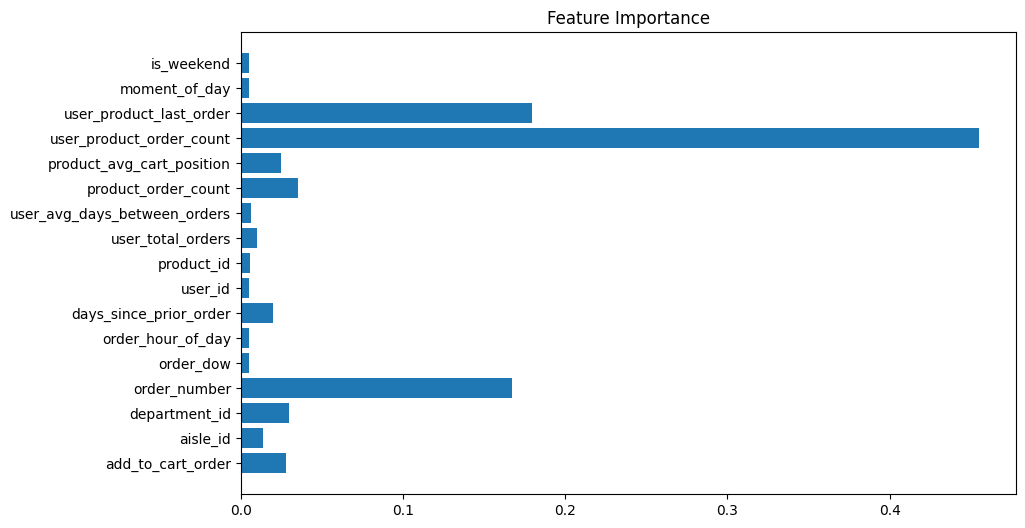

In [59]:
model = pipeline.named_steps["model"]

importances = model.feature_importances_

features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()